# L3: Implicit Diffusion-Reaction

This notebook builds the sparse **gradient** ($\mathbf{G}$) and **divergence** ($\mathbf{D}$) operators used in pymrm, applies **second-order boundary conditions** via Lagrange interpolation, and solves steady-state and transient 1D diffusion-reaction problems using Newton–Raphson iteration.

## Governing equations

Unsteady 1D convection-diffusion-reaction:

$$\frac{\partial c}{\partial t} = -v\frac{\partial c}{\partial z} + D\frac{\partial^2 c}{\partial z^2} + R(c)$$

Written using gradient and divergence operators:

$$\frac{\partial c}{\partial t} = \mathbf{D}\,\mathbf{J}, \quad \mathbf{J} = -v\,c_f + D\,\mathbf{G}\,c$$

**Euler backward** (implicit, unconditionally A-stable):

$$c^{n+1} = c^n + \Delta t\left[\mathbf{D}\left(D\,\mathbf{G}\,c^{n+1} + J_{\text{conv}}\right) + R(c^{n+1})\right]$$

This is a nonlinear system in $c^{n+1}$; linearise with Newton–Raphson.

## Second-order boundary conditions

pymrm uses **Lagrange interpolation** through the boundary face $x_{f,0}$ and the two nearest cell centres $x_{c,0}$, $x_{c,1}$ to evaluate the gradient at the boundary:

$$\left.\frac{dc}{dz}\right|_{z_{f,0}} = \alpha_0\,c_{f,0} + \alpha_1\,c_{c,0} - \alpha_2\,c_{c,1}$$

with Lagrange coefficients $\alpha_0 = \alpha_1 - \alpha_2$, $\alpha_1 = (x_{c,1}-x_{f,0})/[(x_{c,0}-x_{f,0})(x_{c,1}-x_{c,0})]$, $\alpha_2 = (x_{c,0}-x_{f,0})/[(x_{c,1}-x_{f,0})(x_{c,1}-x_{c,0})]$.

The **general Robin boundary condition** is:

$$a\left.\frac{dc}{dn}\right|_{\text{boundary}} + b\,c_f = d$$

| BC type | $a$ | $b$ | $d$ | Meaning |
|---|---|---|---|---|
| Dirichlet | 0 | 1 | $c_w$ | $c = c_w$ at wall |
| Neumann | 1 | 0 | $g_w$ | $dc/dn = g_w$ at wall |
| Robin | 1 | $h/D$ | $h c_\infty/D$ | Film model |

`construct_grad` incorporates these automatically at **second-order accuracy** when `bc=({'a':..,'b':..,'d':..}, {...})` is passed.

## PyMRM building blocks

| Function | Signature | Role |
|---|---|---|
| `construct_grad` | `(shape, x_f, bc=(bc_L, bc_R))` | $\mathbf{G}$: maps cell values → face gradients (2nd-order BCs) |
| `construct_div` | `(shape, x_f, nu=0)` | $\mathbf{D}$: maps face fluxes → cell divergences |
| `construct_convflux_upwind` | `(shape, x_f, bc, v)` | Upwind convective flux matrix |
| `NumJac` | `(shape)` | Finite-difference Jacobian for nonlinear terms |
| `newton` | `(func, x0)` | Newton–Raphson with automatic Jacobian |

## Example 1 — Steady-state diffusion: Dirichlet BCs

Two components counter-diffusing through a slab of thickness $L$, with a fast reaction $A + B \to$ products. Both components have fixed concentrations at the walls.

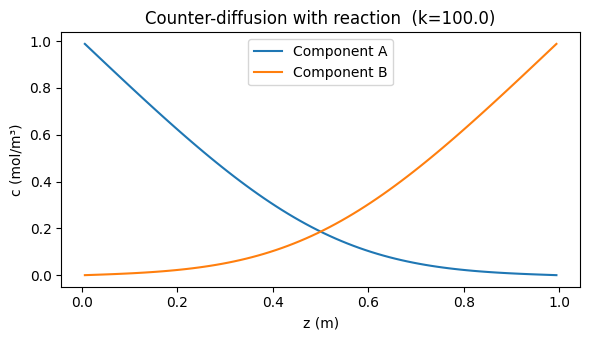

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse.linalg as sla
from pymrm import construct_grad, construct_div, NumJac

# Physical parameters
n_c = 2
L = 1.0
D = 1.0
k = 100.0
bc_L = {'a': 0, 'b': 1, 'd': [1.0, 0.0]}  # Dirichlet: c_A=1, c_B=0 at left
bc_R = {'a': 0, 'b': 1, 'd': [0.0, 1.0]}  # Dirichlet: c_A=0, c_B=1 at right

def reaction(c):
    r = k * c[:, 0] * c[:, 1]
    f = np.empty_like(c)
    f[:, 0] = -r
    f[:, 1] = -r
    return f

# Grid
n_x = 80
shape = (n_x, n_c)
x_f = np.linspace(0, L, n_x + 1)
x_c = 0.5*(x_f[:-1] + x_f[1:])

# Build operators — BCs encoded in Grad (second-order Lagrange)
grad_mat, grad_bc = construct_grad(shape, x_f, x_c, bc=(bc_L, bc_R), axis=0)
div_mat = construct_div(shape, x_f, nu=0, axis=0)
jac_diff = div_mat @ (D * grad_mat)        # diffusion operator
g_diff_bc = div_mat @ (D * grad_bc)  # BC source vector

numjac = NumJac(shape)
c = np.zeros(shape)
for _ in range(12):
    f_rxn, jac_rxn = numjac(reaction, c)
    g = jac_diff @ c.reshape(-1, 1) + g_diff_bc + f_rxn.reshape(-1, 1)
    lu = sla.splu(jac_diff + jac_rxn)
    c -= lu.solve(g).reshape(shape)

plt.figure(figsize=(6, 3.5))
plt.plot(x_c, c[:, 0], label='Component A')
plt.plot(x_c, c[:, 1], label='Component B')
plt.xlabel('z (m)'); plt.ylabel('c (mol/m³)')
plt.title(f'Counter-diffusion with reaction  (k={k})')
plt.legend(); plt.tight_layout(); plt.show()


## Example 2 — Transient diffusion-reaction with general BCs

Unsteady diffusion of a single species with first-order reaction, Dirichlet BC at left ($c=1$), Neumann (zero-flux) at right.

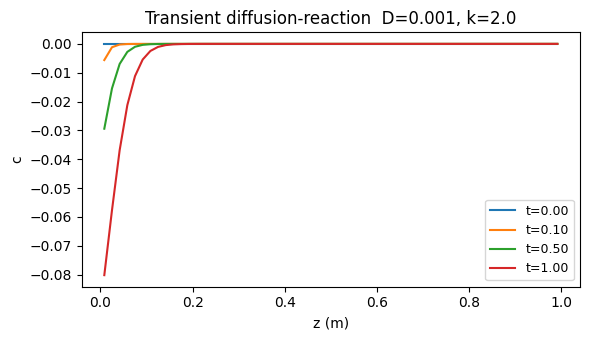

In [2]:
from pymrm import construct_grad, construct_div
import scipy.sparse as sp, scipy.sparse.linalg as sla

n_x, length, d_eff, k_rxn = 60, 1.0, 1e-3, 2.0
x_f = np.linspace(0, length, n_x+1)
x_c = 0.5*(x_f[:-1] + x_f[1:])
dt = 0.05
t_end = 1.0

bc_left  = {'a': 1, 'b': 0, 'd': 1.0}  # Dirichlet: c = 1
bc_right = {'a': 0, 'b': 1, 'd': 0.0}  # Neumann: dc/dn = 0

grad_mat, grad_bc = construct_grad(n_x, x_f, x_c, bc=(bc_left, bc_right))
div_mat = construct_div(n_x, x_f)
jac_diff = div_mat @ (d_eff * grad_mat)
g_diff_bc = div_mat @ (d_eff * grad_bc)

# Backward Euler: (I/dt - L - k*I) c^{n+1} = c^n/dt - bc
A_sys = sp.eye(n_x, format='csc') / dt - jac_diff - k_rxn * sp.eye(n_x, format='csc')
lu = sla.splu(A_sys)

c = np.zeros(n_x)
t = 0.0
snapshots = {}
while t < t_end + 1e-10:
    if any(abs(t - ts) < dt/2 for ts in [0, 0.1, 0.5, 1.0]):
        snapshots[f't={t:.2f}'] = c.copy()
    rhs = c / dt - g_diff_bc.toarray().ravel()
    c = lu.solve(rhs)
    t += dt

plt.figure(figsize=(6, 3.5))
for label, snap in snapshots.items():
    plt.plot(x_c, snap, label=label)
plt.xlabel('z (m)'); plt.ylabel('c')
plt.title(f'Transient diffusion-reaction  D={d_eff}, k={k_rxn}')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()


## Summary

- `construct_grad(shape, x_f, bc=(bc_L, bc_R))` returns `(Grad, grad_bc)` — the BC source vector `grad_bc` carries the inhomogeneous part; add `Div @ D * grad_bc` to the RHS
- BCs are **second-order** via Lagrange interpolation using the two nearest cells — not first-order ghost cells
- Robin form $a\,(dc/dn) + b\,c = d$ covers Dirichlet ($a=0,b=1$), Neumann ($a=1,b=0$), and film-model ($a=1,b=h/D$) conditions
- Backward Euler is unconditionally stable for diffusion; the linear system is solved once per time step by LU factorisation
- For nonlinear kinetics, use `NumJac` for the reaction Jacobian and iterate with Newton–Raphson